========== DATASET ==========
    Age  Salary  Buy
0    20   20000    0
1    25   25000    0
2    30   50000    1
3    35   60000    1
4    40   80000    1
5    22   22000    0
6    28   45000    1
7    45   90000    1
8    32   55000    1
9    38   70000    1
10   27   35000    0
11   31   52000    1
12   36   65000    1
13   42   85000    1
14   24   28000    0
15   29   48000    1
16   34   58000    1
17   41   75000    1
18   26   30000    0
19   37   68000    1

========== MISSING VALUES ==========
Age       0
Salary    0
Buy       0
dtype: int64

========== FEATURES ==========
   Age  Salary
0   20   20000
1   25   25000
2   30   50000
3   35   60000
4   40   80000

========== TARGET ==========
0    0
1    0
2    1
3    1
4    1
Name: Buy, dtype: int64

========== TRAIN TEST SPLIT ==========
X_train: (16, 2)
X_test : (4, 2)
y_train: (16,)
y_test : (4,)

========== MODEL ==========
DecisionTreeClassifier(max_depth=3, random_state=42)

Model Training Completed!

========== TEST PRE

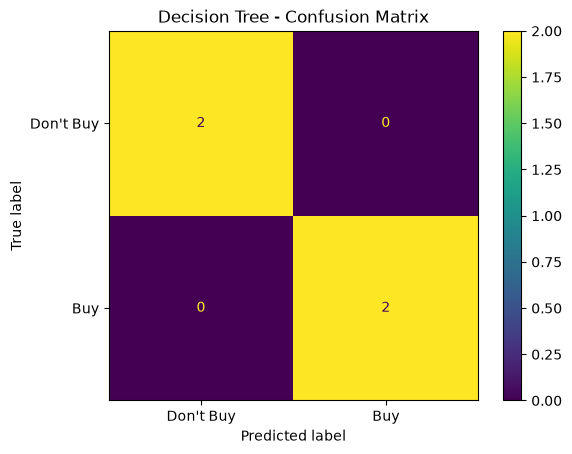


========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

   Don't Buy       1.00      1.00      1.00         2
         Buy       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


========== NEW CUSTOMER ==========
   Age  Salary
0   33   55000

========== NEW PREDICTION ==========
Prediction: [1]
Customer will BUY

========== PREDICTION PROBABILITY ==========
Classes: [0 1]
Probability: [[0. 1.]]
Don't Buy Probability: 0.0
Buy Probability: 1.0


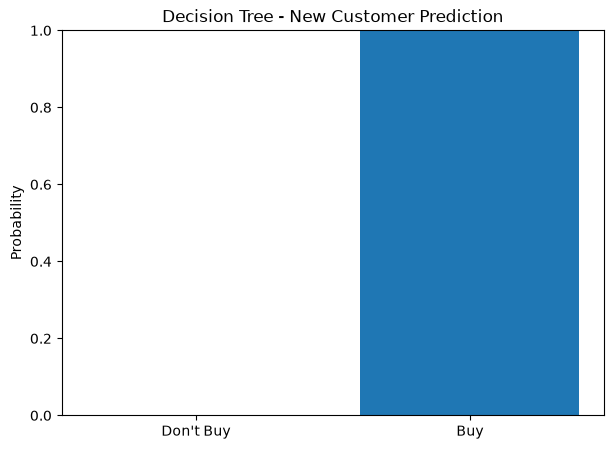

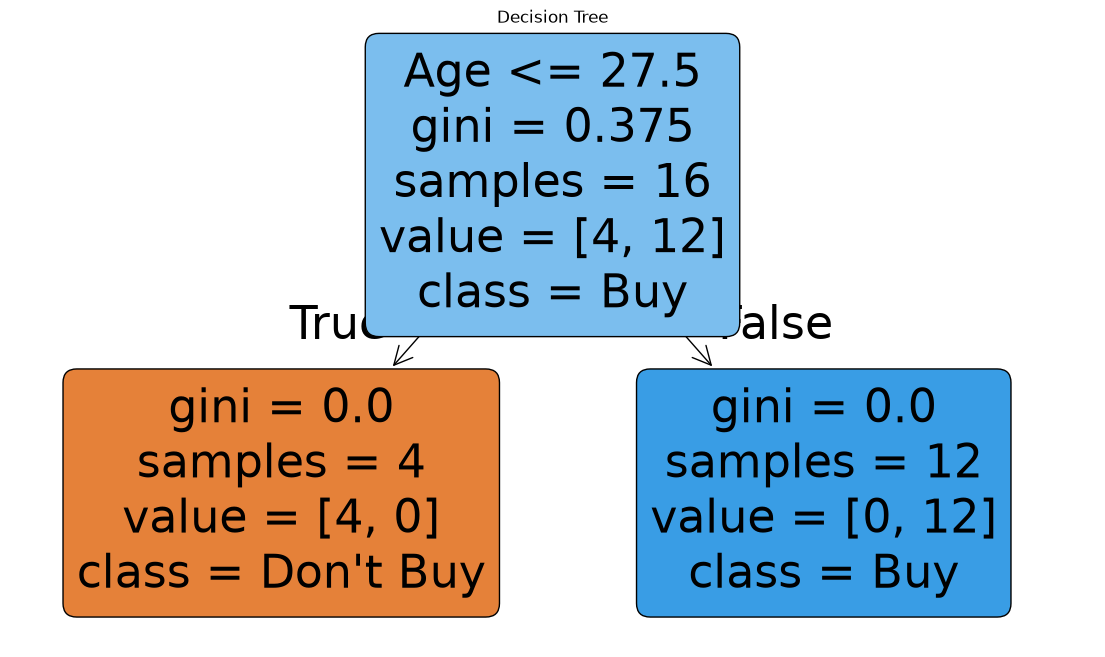


========== FEATURE IMPORTANCE ==========
  Feature  Importance
0     Age         1.0
1  Salary         0.0


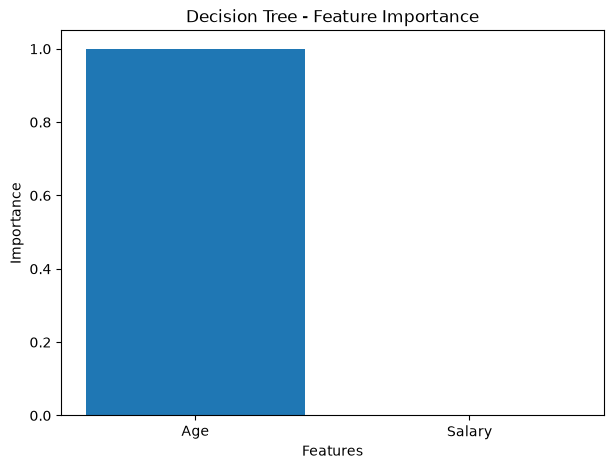


========== ACTUAL VS PREDICTED ==========
   Actual  Predicted
0       0          0
1       1          1
2       1          1
3       0          0


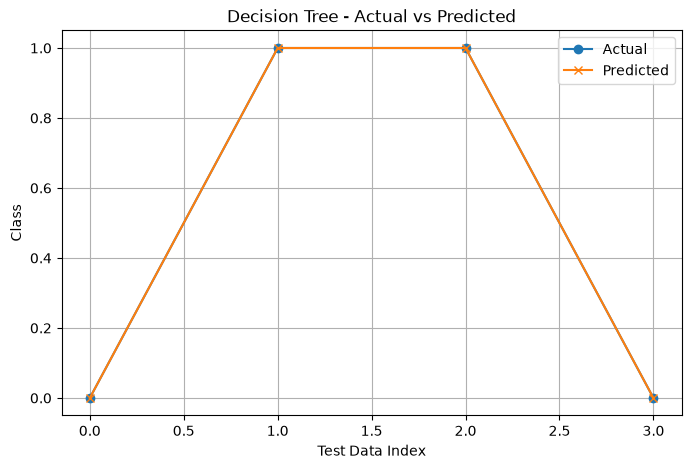

In [2]:
# ==========================================================
# DECISION TREE CLASSIFICATION - COMPLETE PRACTICAL
# Age + Salary -> Buy / Don't Buy
# ==========================================================


# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# ==========================================================
# 2. CREATE DATASET
# ==========================================================

data = {
    "Age": [20, 25, 30, 35, 40, 22, 28, 45, 32, 38,
            27, 31, 36, 42, 24, 29, 34, 41, 26, 37],

    "Salary": [20000, 25000, 50000, 60000, 80000, 22000,
               45000, 90000, 55000, 70000, 35000, 52000,
               65000, 85000, 28000, 48000, 58000, 75000,
               30000, 68000],

    "Buy": [0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
            0, 1, 1, 1, 0, 1, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

print("========== DATASET ==========")
print(df)


# ==========================================================
# 3. CHECK MISSING VALUES
# ==========================================================

print("\n========== MISSING VALUES ==========")

print(df.isnull().sum())


# ==========================================================
# 4. FEATURES AND TARGET
# ==========================================================

X = df[["Age", "Salary"]]

y = df["Buy"]

print("\n========== FEATURES ==========")
print(X.head())

print("\n========== TARGET ==========")
print(y.head())


# ==========================================================
# 5. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n========== TRAIN TEST SPLIT ==========")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==========================================================
# 6. CREATE DECISION TREE MODEL
# ==========================================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

print("\n========== MODEL ==========")

print(model)


# ==========================================================
# 7. TRAIN MODEL
# ==========================================================

model.fit(
    X_train,
    y_train
)

print("\nModel Training Completed!")


# ==========================================================
# 8. TEST DATA PREDICTION
# ==========================================================

y_pred = model.predict(
    X_test
)

print("\n========== TEST PREDICTION ==========")

print("Actual    :", y_test.values)

print("Predicted :", y_pred)


# ==========================================================
# 9. ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========== ACCURACY ==========")

print("Accuracy:", accuracy)

print("Accuracy %:", accuracy * 100)


# ==========================================================
# 10. CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n========== CONFUSION MATRIX ==========")

print(cm)


# ==========================================================
# 11. CONFUSION MATRIX VISUAL
# ==========================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Don't Buy", "Buy"]
)

disp.plot()

plt.title("Decision Tree - Confusion Matrix")

plt.show()


# ==========================================================
# 12. CLASSIFICATION REPORT
# ==========================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Don't Buy", "Buy"]
    )
)


# ==========================================================
# 13. NEW CUSTOMER
# ==========================================================

new_customer = pd.DataFrame({
    "Age": [33],
    "Salary": [55000]
})

print("\n========== NEW CUSTOMER ==========")

print(new_customer)


# ==========================================================
# 14. NEW CUSTOMER PREDICTION
# ==========================================================

prediction = model.predict(
    new_customer
)

print("\n========== NEW PREDICTION ==========")

print("Prediction:", prediction)


# ==========================================================
# 15. IF ELSE
# ==========================================================

if prediction[0] == 1:
    print("Customer will BUY")
else:
    print("Customer will NOT BUY")


# ==========================================================
# 16. PREDICTION PROBABILITY
# ==========================================================

probability = model.predict_proba(
    new_customer
)

print("\n========== PREDICTION PROBABILITY ==========")

print("Classes:", model.classes_)

print("Probability:", probability)

print("Don't Buy Probability:",
      probability[0][0])

print("Buy Probability:",
      probability[0][1])


# ==========================================================
# 17. NEW PREDICTION VISUAL
# ==========================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["Don't Buy", "Buy"],
    probability[0]
)

plt.ylabel("Probability")

plt.title("Decision Tree - New Customer Prediction")

plt.ylim(0, 1)

plt.show()


# ==========================================================
# 18. VISUALIZE DECISION TREE
# ==========================================================

plt.figure(figsize=(14, 8))

plot_tree(
    model,
    feature_names=["Age", "Salary"],
    class_names=["Don't Buy", "Buy"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree")

plt.show()


# ==========================================================
# 19. FEATURE IMPORTANCE
# ==========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print("\n========== FEATURE IMPORTANCE ==========")

print(feature_importance)


# ==========================================================
# 20. FEATURE IMPORTANCE VISUAL
# ==========================================================

plt.figure(figsize=(7, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Decision Tree - Feature Importance")

plt.show()


# ==========================================================
# 21. ACTUAL VS PREDICTED
# ==========================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")

print(comparison)


# ==========================================================
# 22. ACTUAL VS PREDICTED VISUAL
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    marker="o",
    label="Actual"
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    marker="x",
    label="Predicted"
)

plt.xlabel("Test Data Index")

plt.ylabel("Class")

plt.title("Decision Tree - Actual vs Predicted")

plt.legend()

plt.grid(True)

plt.show()